In [15]:
library(ggplot2)
library(foreach)

library(Matrix)

library(foreach)
library(cowplot)
library(geometry)
library(cmaes)
library(DiceDesign)
library(viridis)

In [16]:
options(repr.plot.width = 14, repr.plot.height = 8) # size of plots


parallel = TRUE #if parallel computation (only related to optimization of hyperparameters)
if(parallel){
    library(doMC)
    n_batch = 5
    registerDoMC(cores = n_batch)
    }

save_data = TRUE #if data needs to be saved

optim = FALSE # if optimization of hyperparameters

noise = 0 #observation noise

if(noise == 0){ # adapt the path depending on the noise (first or second scenario)
    save_path = "first_scenario/"
}else{
    save_path = "second_scenario/"
}


### Load the needed function

In [17]:
source("../utils_matrix_triangu.R")
source("utils_triangu.R")
source("../utils_plot.R")
source("../utils_splines.R")

### Build triangulation

In [18]:
min_h = 0 #bounds of the cylinder
max_h = 10

jacob = jacob_cylindre # indicate that we work with the Jacobian matrix associated to the cylindrical coordinates
set.seed(13)
list_tri = build_triangu(min_h = min_h, max_h = max_h, radius = 1, n_circ =70) #build triangulation with 70 nodes on each section

design = lhsDesign(10, 2, seed=10)$design #LHS design
design = maximinESE_LHS(design)$design # Maximin LHS

design[,1] = design[,1]*360
design[,2] = design[,2]*(max_h-min_h)+min_h

dist2 = function(x1,x2){return(sum((x1-x2)^2))}

if(noise == 0){
    idx_obs = apply(design, 1, function(x){which.min(apply(list_tri$points_2d,1, function(y){dist2(x,y)}))})  # Find the closest points in the triangulation
    design = as.data.frame(list_tri$points_2d[idx_obs,]) # design is made of these triangulation points
    A = A_func(list_tri = list_tri, sparse = TRUE, all_in_tri = TRUE, idx_obs  = idx_obs) #compute projection matrix
}else{
    A = A_func(points_mes = design ,list_tri = list_tri, sparse = TRUE, all_in_tri = FALSE, parallel = parallel) #compute projection matrix
    }

colnames(design) = c("theta","z")
design = as.data.frame(design)

if(save_data){write.csv(design,paste(save_path , "design.csv", sep=""), row.names = FALSE)} #save design

### Test function 

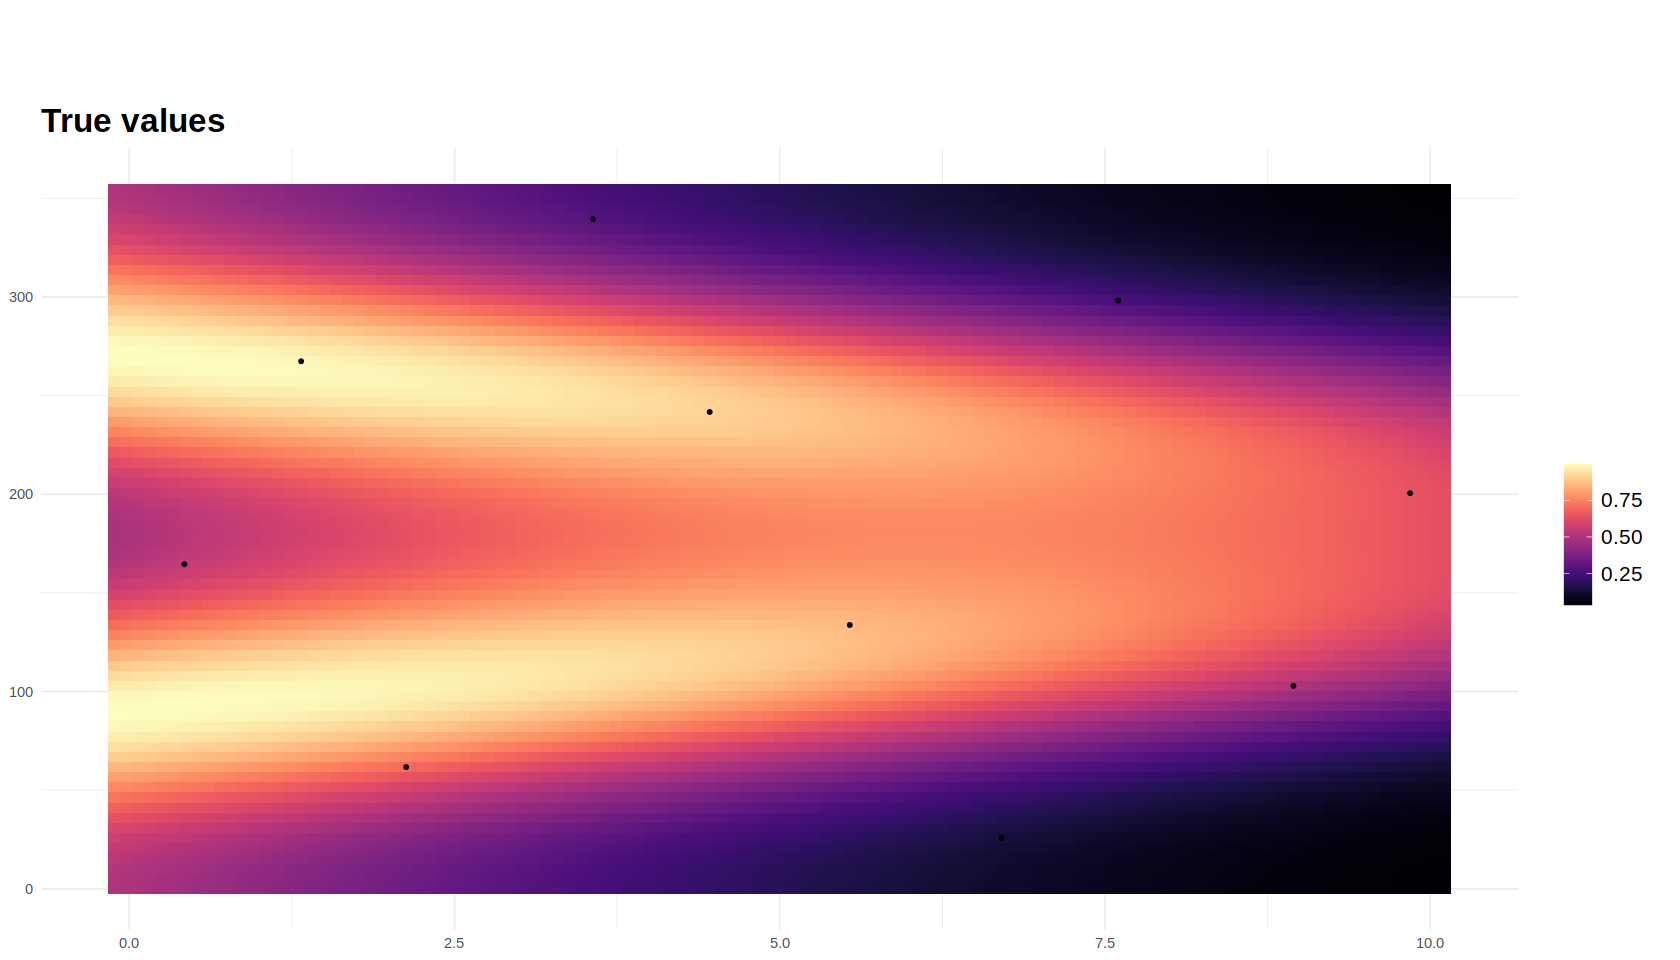

In [19]:
f_cyl = function(xx){
  angle = pi/5
  vec_bis = diag(c(0.5,1.5))%*%cbind(c(cos(angle), sin(angle)), c(-sin(angle), cos(angle)))%*%c(cos(xx[1]*pi/180), xx[2]/max_h)
 return(exp(-sum(vec_bis^2)*3/4))
} # Analytical function to predict

df_test = list_tri$points_2d # The prediction points are the triangulation points
df_test$pred = apply(df_test, 1, f_cyl)

if(save_data){write.csv(df_test, paste(save_path , "df_test.csv", sep=""), row.names = FALSE)}

df_train = design
df_train$y = apply(df_train, 1, f_cyl) #compute values at observation points

plot_multiple_df(list(df_test), coords = c("z","theta"), value = "pred", name = "", list_titles = c("True values"), ncol=1, list_opt = list(df_train[,c("z","theta")]))



### Prediction with isotropic finite-element splines

In [ ]:
list_augmented = augmented_matrices(list_tri, var_a0 = NULL) #Compute matrices needed for the method: sqrt_M S^2 sqrt_M,  1/sqrt(alpha)(Mphi0), phi0, and alpha

var_a0 = list_augmented$var_a0 #return the computed alpha
pred_iso = pred_func(list_tri=list_tri,y = df_train$y, AA = A, idx_obs = idx_obs,list_augmented=list_augmented, noise = noise) #prediction at the triangulation points

df_pred_iso = cbind(list_tri$points_2d, pred_iso) # prediction matrix

colnames(df_pred_iso) = c("theta","z","pred")

if(save_data){write.csv(df_pred_iso,  paste(save_path , "df_pred_iso.csv", sep=""), row.names = FALSE)}

plot_multiple_df(list(df_test, df_pred_iso), coords = c("z","theta"), value = "pred", name = "", list_titles = c("True values", "Isotropic splines"), ncol=2, list_opt = list(df_train[,c("z","theta")],df_train[,c("z","theta")]))

### Optimization of the anistropy parameters

In [ ]:
if(optim){
    lambd = 5 # lambda in cmaes
    budget = 500  #budget for optimization: number of likelihood computations
    path = paste(save_path , "eval_cma.csv", sep="") 

    fun=function(param){return(-ll_func(param, list_tri = list_tri, AA = A, y = df_train$y, var_a0 = var_a0, idx_obs = idx_obs, noise = noise))} #likelihood function

    f_vec <- function(X, save = TRUE) { #vectorize the likelihood function for parallel optimization, and save the results
        df_follow = as.matrix(read.csv(path))
        if(parallel){res = as.numeric(mclapply(1:ncol(X), function(i) fun(X[,i]), mc.cores = lambd))}
        else{res = as.numeric(sapply(1:ncol(X), function(i) fun(X[,i])))}                                
        if(save){write.csv(rbind(df_follow,cbind(t(X), res)), path, row.names = FALSE)}
      return(res)
    }

    write.csv( data.frame(t(rep(0, 4))), path, row.names = FALSE)  #this csv file will contains all likelihood evaluations
    st = Sys.time()
    set.seed(100)
    opt_cma=cma_es(par = c(pi/4,1,1), fn = f_vec, lower= c(0,0.01,0.01), upper =c(pi/2-0.01,20,20), control = list(maxit = budget%/%lambd, lambda = lambd,keep.best = TRUE, diag.pop=TRUE, diag.value = TRUE, sigma = 0.2, diag.sigma = TRUE, vectorized=TRUE)) # optimization with cmaes
    df_follow = as.matrix(read.csv(path))[-1,]
    dur = Sys.time()-st
    df_follow = as.matrix(read.csv(path))[-1,]
    psi_opt = as.numeric(df_follow[which.min(df_follow[,4]),1:3]) #get best parameters

    write.csv( data.frame(t(psi_opt)),  paste(save_path , "psi_opt.csv", sep="") , row.names = FALSE) #save best parameters
}

### Prediction with anisotropic finite-element splines

In [ ]:
psi_opt = as.numeric(read.csv(  paste(save_path , "psi_opt.csv", sep="")))  #get best parameters

pred_aniso = pred_func(list_tri=list_tri,y = df_train$y, AA = A, idx_obs = idx_obs, var_a0 = var_a0, theta = psi_opt[1], rho = psi_opt[2:3], noise = noise) #anisotropic prediction

df_pred_aniso = cbind(list_tri$points_2d, pred_aniso)

colnames(df_pred_aniso) = c("theta","z","pred")

if(save_data){write.csv(df_pred_aniso, file =  paste(save_path , "df_pred_aniso.csv", sep="") ,row.names = FALSE)}

plot_multiple_df(list(df_test,df_pred_aniso), coords = c("z","theta"), value = "pred", name = "", list_titles = c("True values", "Anisotropic splines"), ncol=2, list_opt = list(df_train[,c("z","theta")],df_train[,c("z","theta")]))